| **Team Member**           | **Contributions**                                                                                                                                         |
|---------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Urjeet Parmar**         | - Prepared & cleaned dataset (tokenization, stopwords, lemmatization).<br>- Built initial NB model with one-hot (unigram+bigram) features.                |
| **Devendra Singh Sekhawat** | - Tuned NB models (GridSearchCV, alpha) and compared vectorizers.<br>- Integrated LIME/SHAP for local/global interpretability.                          |


    Negative Class: Precision = 0.81, Recall = 0.74, F1-score = 0.77
    Neutral Class: Precision = 0.38, Recall = 0.13, F1-score = 0.19
    Positive Class: Precision = 0.84, Recall = 0.95, F1-score = 0.89
    Overall Accuracy: 0.82
    Macro Average F1-score: 0.62
    Weighted Average F1-score: 0.79
    Best Cross-Validation Accuracy (Grid Search): 0.8200
    AUC Score: 0.8328

#1.Importing Necessary libraries

>



In [ ]:
pip install lime


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter
import lime
from lime.lime_text import LimeTextExplainer
# Machine Learning & Evaluation
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline

# WordCloud
from wordcloud import WordCloud


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Loaded Dataset and Dropped Null Values and it contains over 20k Reviews and ratings
df = pd.read_csv('data/yelp.csv').dropna()
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (10000, 2)


,text,stars
0,"I hate to say it. I really, really do.\nThe Ox...",3.0
1,Gray Fox Realty has demonstrated their ability...,5.0
2,Local here. Sorry to leave this review but the...,2.0
3,We make it a point to visit NOLA once or twice...,4.0
4,"Bomb.com \nThey have the most Delicious soups,...",5.0


#3. Map Star Ratings to Sentiment Classes

In [ ]:
#Mapped Ratings according to stars
def map_sentiment(stars):
    if stars >= 4:
        return 1  # Positive
    elif stars <= 2:
        return -1  # Negative
    else:
        return 0   # Neutral

df['sentiment'] = df['stars'].apply(map_sentiment)


#4. Preprocessing Function

In [ ]:
#Removed Stop Words
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    tokens = word_tokenize(text.lower())
    filtered_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token.isalnum() and token not in stop_words
    ]
    return " ".join(filtered_tokens)

df['text'] = df['text'].apply(preprocess_text)


#5. Train-Test Split

In [ ]:
#Splitting the data into a way such that a test set contains more than 5000 rows
X = df['text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.26,
    stratify=y,
    random_state=42
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 7400
Test set size: 2600


#6. Building a Pipeline and Parameter Grid
6.1 Pipeline Explanation

    We want to try both CountVectorizer (with binary=True, ngram_range=(1,2)) and TfidfVectorizer (with the same n-gram range).
    We also want to try MultinomialNB, ComplementNB, and BernoulliNB.
    We’ll tune the alpha parameter for smoothing.

In [ ]:
#Defined a Pipeline to test on diffrent Naive Baiyes Models
pipeline = Pipeline([
    ('vect', CountVectorizer()),  # default, but we'll override in param_grid
    ('clf', MultinomialNB())
])


We’ll create a list of dictionaries, each specifying a combination of vectorizer and classifier we want to test:

In [ ]:
param_grid = [
    # ----- 1) CountVectorizer + MultinomialNB -----
    {
        'vect': [CountVectorizer(binary=True, ngram_range=(1,2))],
        'clf': [MultinomialNB()],
        'clf__alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    # ----- 2) CountVectorizer + ComplementNB -----
    # {
    #     'vect': [CountVectorizer(binary=True, ngram_range=(1,2))],
    #     'clf': [ComplementNB()],
    #     'clf__alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
    # },
    # # ----- 3) CountVectorizer + BernoulliNB -----
    # {
    #     'vect': [CountVectorizer(binary=True, ngram_range=(1,2))],
    #     'clf': [BernoulliNB()],
    #     'clf__alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
    # },
    # # ----- 4) TfidfVectorizer + MultinomialNB -----
    # {
    #     'vect': [TfidfVectorizer(ngram_range=(1,2))],
    #     'clf': [MultinomialNB()],
    #     'clf__alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
    # },
    # # ----- 5) TfidfVectorizer + ComplementNB -----
    # {
    #     'vect': [TfidfVectorizer(ngram_range=(1,2))],
    #     'clf': [ComplementNB()],
    #     'clf__alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
    # },
    # # ----- 6) TfidfVectorizer + BernoulliNB -----
    # {
    #     'vect': [TfidfVectorizer(ngram_range=(1,2))],
    #     'clf': [BernoulliNB()],
    #     'clf__alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
    # }
]


# 7. Grid Search with Cross-Validation

In [ ]:
#Defined a function for gridsearch Cross-validation
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,      # 5-fold cross validation
    n_jobs=-1, # use all cores
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('vect', CountVectorizer()),
                                       ('clf', MultinomialNB())]),
             n_jobs=-1,
             param_grid=[{'clf': [MultinomialNB()],
                          'clf__alpha': [0.01, 0.1, 0.5, 1.0, 2.0],
                          'vect': [CountVectorizer(binary=True,
                                                   ngram_range=(1, 2))]}],
             scoring='accuracy', verbose=1)

8. Best Model Selection

In [ ]:
print("\n=== Grid Search Results ===")
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

best_pipeline = grid_search.best_estimator_



=== Grid Search Results ===
Best Parameters: {'clf': MultinomialNB(), 'clf__alpha': 0.1, 'vect': CountVectorizer(binary=True, ngram_range=(1, 2))}
Best CV Accuracy: 0.8200000000000001


#9. Evaluate on Test Set

In [ ]:
# Predict on test set
y_pred_best = best_pipeline.predict(X_test)

# For multi-class AUC, we need predict_proba
y_proba_best = best_pipeline.predict_proba(X_test)

print("\n=== Tuned Model on Test Set ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Classification Report:\n", classification_report(y_test, y_pred_best, target_names=['Negative','Neutral','Positive']))
print("AUC Score:", roc_auc_score(y_test, y_proba_best, multi_class='ovr'))



=== Tuned Model on Test Set ===
Confusion Matrix:
 [[ 457   37  124]
 [  42   34  188]
 [  63   18 1637]]
Classification Report:
               precision    recall  f1-score   support

    Negative       0.81      0.74      0.77       618
     Neutral       0.38      0.13      0.19       264
    Positive       0.84      0.95      0.89      1718

    accuracy                           0.82      2600
   macro avg       0.68      0.61      0.62      2600
weighted avg       0.79      0.82      0.79      2600

AUC Score: 0.8327537713131757


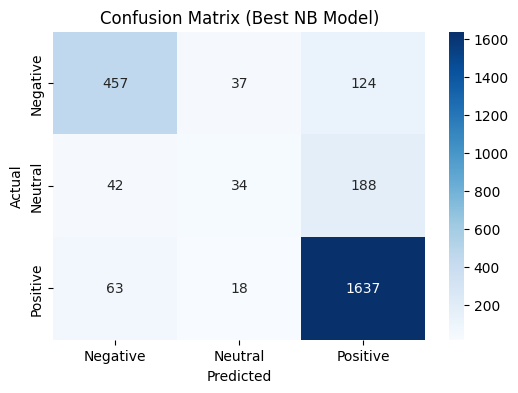

In [ ]:
conf_mat = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(conf_mat, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix (Best NB Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


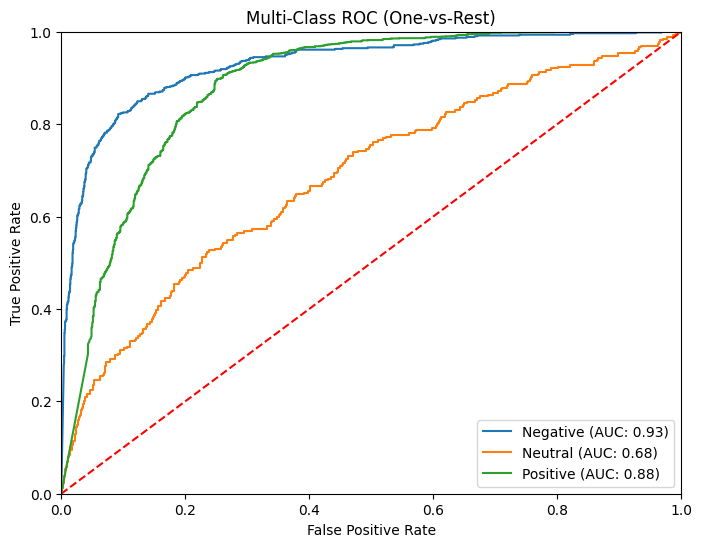

In [ ]:
# Our classes = [-1, 0, 1]
all_classes = [-1, 0, 1]
y_test_binarized = label_binarize(y_test, classes=all_classes)
y_proba_binarized = y_proba_best  # shape [n_samples, 3]

plt.figure(figsize=(8,6))
for i, class_label in enumerate(all_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_proba_binarized[:, i])
    roc_auc = auc(fpr, tpr)

    if class_label == -1:
        label_name = 'Negative'
    elif class_label == 0:
        label_name = 'Neutral'
    else:
        label_name = 'Positive'

    plt.plot(fpr, tpr, label=f"{label_name} (AUC: {roc_auc:.2f})")

plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC (One-vs-Rest)')
plt.legend()
plt.show()


In [ ]:
#Word clouds for each type of reviews
negative_text = " ".join(df[df['sentiment'] == -1]['text'].tolist())
neutral_text  = " ".join(df[df['sentiment'] ==  0]['text'].tolist())
positive_text = " ".join(df[df['sentiment'] ==  1]['text'].tolist())

wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_text)
wordcloud_neu = WordCloud(width=800, height=400, background_color='white').generate(neutral_text)
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)




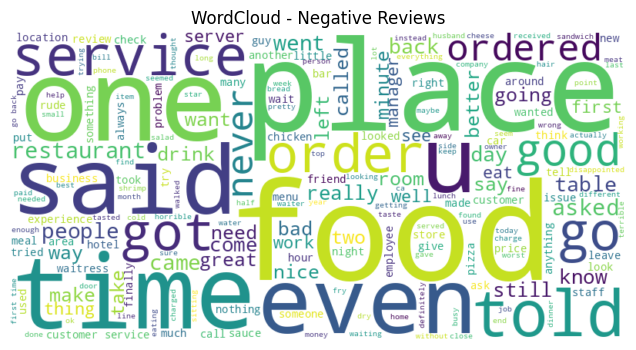

In [ ]:
# Plot each WordCloud
plt.figure(figsize=(8,4))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title("WordCloud - Negative Reviews")
plt.axis('off')
plt.show()



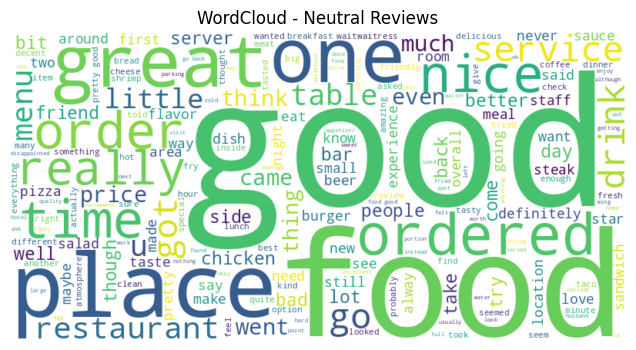

In [ ]:
plt.figure(figsize=(8,4))
plt.imshow(wordcloud_neu, interpolation='bilinear')
plt.title("WordCloud - Neutral Reviews")
plt.axis('off')
plt.show()



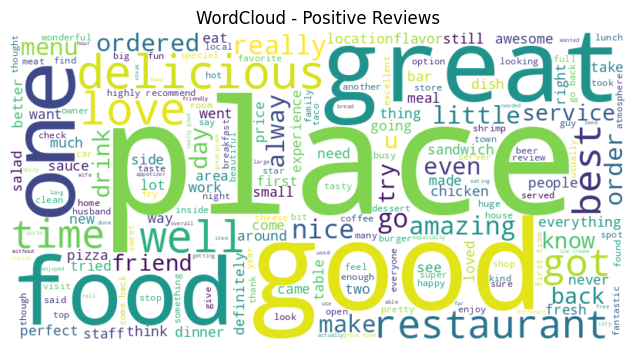

In [ ]:
plt.figure(figsize=(8,4))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title("WordCloud - Positive Reviews")
plt.axis('off')
plt.show()

In [ ]:

# Split into individual tokens
neg_tokens = negative_text.split()
neu_tokens = neutral_text.split()
pos_tokens = positive_text.split()

# Count word frequencies
neg_counts = Counter(neg_tokens)
neu_counts = Counter(neu_tokens)
pos_counts = Counter(pos_tokens)

# Get top 20 for each (or any number you want)
top_neg = neg_counts.most_common(20)
top_neu = neu_counts.most_common(20)
top_pos = pos_counts.most_common(20)


In [ ]:
print("=== Top 20 Negative Words ===")
for word, freq in top_neg:
    print(f"{word}: {freq}")

print("\n=== Top 20 Neutral Words ===")
for word, freq in top_neu:
    print(f"{word}: {freq}")

print("\n=== Top 20 Positive Words ===")
for word, freq in top_pos:
    print(f"{word}: {freq}")


=== Top 20 Negative Words ===
food: 1500
time: 1305
would: 1278
place: 1184
get: 1122
service: 1071
like: 1024
one: 1007
back: 978
u: 851
go: 808
good: 785
order: 767
could: 758
even: 742
never: 697
said: 671
told: 660
got: 643
minute: 593

=== Top 20 Neutral Words ===
good: 798
food: 714
place: 561
like: 465
would: 458
time: 443
get: 380
one: 378
great: 374
service: 360
ordered: 313
back: 313
go: 311
really: 283
also: 280
nice: 264
pretty: 255
drink: 245
order: 244
restaurant: 236

=== Top 20 Positive Words ===
great: 3732
place: 3334
food: 3269
good: 3019
time: 2248
service: 2028
get: 1783
like: 1732
back: 1671
one: 1648
go: 1564
would: 1514
really: 1476
also: 1433
best: 1429
delicious: 1332
love: 1310
friendly: 1260
nice: 1230
always: 1186


In [ ]:
# Map sentiment integer -> text labels if needed
class_names = ['Negative', 'Neutral', 'Positive']

explainer = LimeTextExplainer(class_names=class_names)


In [ ]:
# We'll pick one sample from X_test to interpret
# If X_test is a pandas Series of text reviews, e.g., X_test.iloc[0]
test_instance = X_test.iloc[0]  # or X_test[0] if X_test is a NumPy array

print("Review text:")
print(test_instance)


Review text:
cajun food excellent service excellent price reasonable bar looking upscale place looking best crawfish ettouffe north louisiana definitely place


In [ ]:
# LIME expects a function that takes a list of raw text docs -> predicted probabilities
def predict_proba_for_lime(texts):
    """
    LIME calls this function with a list of text strings.
    We'll feed them into the best_pipeline (which vectorizes + predicts).
    """
    return best_pipeline.predict_proba(texts)

# Explain this particular instance
explanation = explainer.explain_instance(
    test_instance,              # the raw text to explain
    predict_proba_for_lime,     # function that returns prediction probabilities
    num_features=10,            # how many "words" to show
    labels=[0,1,2]              # which label indices to explain; 0->Negative,1->Neutral,2->Positive
)

# Display the explanation in a notebook (Jupyter, Colab, etc.)
explanation.show_in_notebook(text=True)
